# <b>Climate Impacts on Portugal's Fishing Industry Capstone Project</b>
# Part 1: Data Cleaning
Author: Daisy Chu
<br>Date: 3/27/2026</br>
## Environmental Research Question: 
- How does ocean temperature impact the number of fish landings in Portugal?
- How does ocean temperature and number of fish landings affect the national fish price?

Link to GitHub repository: [GitHub Repository](<https://github.com/daisychu12/pt-fisheries-climate-change>)

## Loading Data

In [28]:
# Load libraries
library(dplyr)
library(ggplot2)
library(tidyverse)
library(ggpubr)
library(Hmisc)

In [35]:
# Set directory to the raw_data subfolder and check files
setwd("../data/raw_data")
list.files()

[1] "ASFIS_sp_2025.csv"             "atlantic_ocean_temp.csv"      
[3] "countries_iso3166b.csv"        "ICES_1950-2010.csv"           
[5] "ICESCatchDataset2006-2023.csv" "portugal_fishery_stats.csv"   
[7] "README.md"

In [30]:
# Load raw datasets
landings_1950 <- read.csv("ICES_1950-2010.csv")
landings_2006 <- read.csv("ICESCatchDataset2006-2023.csv")
iso_code <- read.csv("countries_iso3166b.csv")
spec_names <- read.csv("ASFIS_sp_2025.csv")
fish_cost <- read.csv("portugal_fishery_stats.csv")
atlantic_climate <- read.csv("atlantic_ocean_temp.csv")

In [32]:
# Explore datasets
head(landings_1950)
head(landings_2006)
head(fish_cost)
head(atlantic_climate)

,Country,Species,Division,X1950,X1951,X1952,X1953,X1954,X1955,X1956,⋯,X2001,X2002,X2003,X2004,X2005,X2006,X2007,X2008,X2009,X2010
,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,⋯,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>
1,Belgium,Anglerfishes nei,IV b,.,.,.,.,.,.,.,⋯,.,.,.,.,.,138,179,181,134,124
2,Belgium,Anglerfishes nei,IV c,.,.,.,.,.,.,.,⋯,.,.,.,.,.,3,3,4,6,7
3,Belgium,Anglerfishes nei,VII a,.,.,.,.,.,.,.,⋯,.,.,.,.,.,69,73,29,19,19
4,Belgium,Anglerfishes nei,VII b,.,.,.,.,.,.,.,⋯,.,.,.,.,.,-,1,-,.,.
5,Belgium,Anglerfishes nei,VII d,.,.,.,.,.,.,.,⋯,.,.,.,.,.,21,44,43,56,127
6,Belgium,Anglerfishes nei,VII e,.,.,.,.,.,.,.,⋯,.,.,.,.,.,217,242,101,73,94


,Species,Area,Units,Country,X2023,X2022,X2021,X2020,X2019,X2018,⋯,X2015,X2014,X2013,X2012,X2011,X2010,X2009,X2008,X2007,X2006
,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
1,AAC,27,TLW,PT,0 c,0,0,0,0,0,⋯,0,0,0.00,0,0,0,0,0,0,0
2,AAC,27.9,TLW,PT,0 c,0,0,0,0,0,⋯,0,0,0.00,0,0,0,0,0,0,0
3,AAC,27.9.a,TLW,PT,0 c,0,0,0,0,0,⋯,0,0,0.00,0,0,0,0,0,0,0
4,AAS,27,TLW,DK,0,0,0,0,0,0,⋯,0,0,0.23,0,0,0,0,0,0,0
5,AAS,27.3,TLW,DK,0,0,0,0,0,0,⋯,0,0,0.23,0,0,0,0,0,0,0
6,AAS,27.4,TLW,DK,0,0,0,0,0,0,⋯,0,0,0.00,0,0,0,0,0,0,0


,year,price.of.fish..euros.kg.
,<int>,<dbl>
1,2024,2.62
2,2023,2.47
3,2022,2.65
4,2021,2.28
5,2020,2.30
6,2019,2.08


,year,max,min
,<int>,<dbl>,<dbl>
1,1859,-0.44,-0.48
2,1860,-0.47,-0.49
3,1861,-0.51,-0.52
4,1862,-0.55,-0.60
5,1863,-0.36,-0.61
6,1864,-0.37,-0.63


## Cleaning Data

In [33]:
# First let's clean the fish cost and atlantic ocean temp datasets
# Clean column names
fish_cost_clean <- fish_cost %>%
  rename(price = price.of.fish..euros.kg.)

atl_clim_clean <- atlantic_climate %>%
  rename(max_temp = max,
         min_temp = min)

# Take a look at the new column names
head(fish_cost_clean)
head(atl_clim_clean)

,year,price
,<int>,<dbl>
1,2024,2.62
2,2023,2.47
3,2022,2.65
4,2021,2.28
5,2020,2.30
6,2019,2.08


,year,max_temp,min_temp
,<int>,<dbl>,<dbl>
1,1859,-0.44,-0.48
2,1860,-0.47,-0.49
3,1861,-0.51,-0.52
4,1862,-0.55,-0.60
5,1863,-0.36,-0.61
6,1864,-0.37,-0.63


In [34]:
# Clean each of the landings datasets
landings_1950_clean <- landings_1950 %>%
# Tidy up column names of each fish landings dataset
  rename(country = Country,
         species_name = Species,
         fao_division = Division) %>%
  rename_with(~ str_remove(., "^X")) %>%
# Convert the landings for each year to numeric data type
  mutate(across("1950":"2010", as.numeric)) %>%
# To prevent a repeat of data from 2006-2010 when merging datasets,
# remove these columns first from the 1950s dataset
  select(-"2006":-"2010")  

landings_2006_clean <- landings_2006 %>%
# Tidy up column names of each fish landings dataset
  rename(species_code = Species,
         fao_area = Area,
         units = Units,
         country = Country) %>%
  rename_with(~ str_remove(., "^X")) %>%
# Convert the landings for each year to numeric data type
  mutate(across("2006":"2023", as.numeric))

# Let's take a look at the cleaned dataframes
head(landings_1950_clean)
head(landings_2006_clean)

Warning message:
“There were 61 warnings in `mutate()`.
The first warning was:
ℹ In argument: `across("1950":"2010", as.numeric)`.
Caused by warning:
! NAs introduced by coercion
ℹ Run `dplyr::last_dplyr_warnings()` to see the 60 remaining warnings.”


Warning message:
“There were 2 warnings in `mutate()`.
The first warning was:
ℹ In argument: `across("2006":"2023", as.numeric)`.
Caused by warning:
! NAs introduced by coercion
ℹ Run `dplyr::last_dplyr_warnings()` to see the 1 remaining warning.”


,country,species_name,fao_division,1950,1951,1952,1953,1954,1955,1956,⋯,1996,1997,1998,1999,2000,2001,2002,2003,2004,2005
,<chr>,<chr>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
1,Belgium,Anglerfishes nei,IV b,NA,NA,NA,NA,NA,NA,NA,⋯,NA,NA,NA,NA,NA,NA,NA,NA,NA,NA
2,Belgium,Anglerfishes nei,IV c,NA,NA,NA,NA,NA,NA,NA,⋯,NA,NA,NA,NA,NA,NA,NA,NA,NA,NA
3,Belgium,Anglerfishes nei,VII a,NA,NA,NA,NA,NA,NA,NA,⋯,NA,NA,NA,NA,NA,NA,NA,NA,NA,NA
4,Belgium,Anglerfishes nei,VII b,NA,NA,NA,NA,NA,NA,NA,⋯,NA,NA,NA,NA,NA,NA,NA,NA,NA,NA
5,Belgium,Anglerfishes nei,VII d,NA,NA,NA,NA,NA,NA,NA,⋯,NA,NA,NA,NA,NA,NA,NA,NA,NA,NA
6,Belgium,Anglerfishes nei,VII e,NA,NA,NA,NA,NA,NA,NA,⋯,NA,NA,NA,NA,NA,NA,NA,NA,NA,NA


,species_code,fao_area,units,country,2023,2022,2021,2020,2019,2018,⋯,2015,2014,2013,2012,2011,2010,2009,2008,2007,2006
,<chr>,<chr>,<chr>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
1,AAC,27,TLW,PT,NA,0,0,0,0,0,⋯,0,0,0.00,0,0,0,0,0,0,0
2,AAC,27.9,TLW,PT,NA,0,0,0,0,0,⋯,0,0,0.00,0,0,0,0,0,0,0
3,AAC,27.9.a,TLW,PT,NA,0,0,0,0,0,⋯,0,0,0.00,0,0,0,0,0,0,0
4,AAS,27,TLW,DK,0,0,0,0,0,0,⋯,0,0,0.23,0,0,0,0,0,0,0
5,AAS,27.3,TLW,DK,0,0,0,0,0,0,⋯,0,0,0.23,0,0,0,0,0,0,0
6,AAS,27.4,TLW,DK,0,0,0,0,0,0,⋯,0,0,0.00,0,0,0,0,0,0,0


In [36]:
# Create a dataset that contains both species 3 letter code and name
spec_code_name <- spec_names %>%
  select(Alpha3_Code, English_name) %>%
  rename(species_code = Alpha3_Code,
         species_name = English_name)

head(spec_code_name)

,species_code,species_name
,<chr>,<chr>
1,GXM,Siamese algae-eater
2,CDO,River carpsucker
3,FMP,Quillback
4,ATC,Longnose sucker
5,ATO,White sucker
6,ATS,Flannelmouth sucker


In [37]:
# Filter to Portugal's fish landings for all datasets
# Use iso_code to find Portugal's repsective iso codes
portugal <- iso_code %>%
  filter(country == "Portugal")

# The 1950s dataset uses only the country name: Portugal
pt_landings_1950 <- landings_1950_clean %>%
  filter(country == "Portugal") %>%
  left_join(spec_code_name, by = "species_name")

# The 2006 dataset uses the two letter iso code: PT
pt_landings_2006 <- landings_2006_clean %>%
  filter(country == "PT") %>%
  left_join(spec_code_name, by = "species_code")

# Let's take a look
head(pt_landings_1950)
head(pt_landings_2006)

,country,species_name,fao_division,1950,1951,1952,1953,1954,1955,1956,⋯,1997,1998,1999,2000,2001,2002,2003,2004,2005,species_code
,<chr>,<chr>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>
1,Portugal,African striped grunt,IX (not specified),NA,NA,NA,NA,NA,NA,NA,⋯,1,6,4,NA,NA,NA,1,NA,10,GRA
2,Portugal,African striped grunt,IX a,NA,NA,NA,NA,NA,NA,NA,⋯,NA,NA,NA,NA,NA,NA,NA,7,1,GRA
3,Portugal,Albacore,ICES Area (not specified),NA,NA,NA,NA,NA,NA,NA,⋯,NA,NA,165,22,38,NA,NA,NA,NA,ALB
4,Portugal,Albacore,IX (not specified),NA,NA,NA,NA,NA,NA,NA,⋯,2,12,4,2,NA,1,1,85,16,ALB
5,Portugal,Albacore,IX a,NA,NA,NA,NA,NA,NA,NA,⋯,NA,NA,NA,NA,NA,NA,NA,2,NA,ALB
6,Portugal,Albacore,IX b (not specified),NA,NA,NA,NA,NA,NA,NA,⋯,NA,NA,NA,NA,NA,NA,NA,NA,3,ALB


,species_code,fao_area,units,country,2023,2022,2021,2020,2019,2018,⋯,2014,2013,2012,2011,2010,2009,2008,2007,2006,species_name
,<chr>,<chr>,<chr>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>
1,AAC,27,TLW,PT,NA,0.00,0,0.00,0,0,⋯,0.00,0.00,0.00,0,0,0,0,0,0,Bowfin
2,AAC,27.9,TLW,PT,NA,0.00,0,0.00,0,0,⋯,0.00,0.00,0.00,0,0,0,0,0,0,Bowfin
3,AAC,27.9.a,TLW,PT,NA,0.00,0,0.00,0,0,⋯,0.00,0.00,0.00,0,0,0,0,0,0,Bowfin
4,ABX,27,TLW,PT,0,0.44,0,0.01,0,0,⋯,4.84,0.01,2.85,0,0,0,0,0,0,Abalones NEI
5,ABX,27.10,TLW,PT,0,0.00,0,0.00,0,0,⋯,0.41,0.00,0.24,0,0,0,0,0,0,Abalones NEI
6,ABX,27.9,TLW,PT,0,0.44,0,0.01,0,0,⋯,4.43,0.01,2.62,0,0,0,0,0,0,Abalones NEI


In [38]:
#Determine shared species across the 3 datasets
unique_species_1950 <- unique(pt_landings_1950$species_name)
unique_species_2006 <- unique(pt_landings_2006$species_code)

# Which dataset has less unique species
length(unique_species_1950)
length(unique_species_2006)

# It looks like the 1950s dataset has less unique species, therefore we'll look at the species present in that dataset

[1] 502

[1] 708

In [39]:
# Combine datasets
# First group by species and sum landings within each dataset
pt_landings_1950_group <- pt_landings_1950 %>%
  group_by(species_name, species_code) %>%
  summarise(across(where(is.numeric), sum, na.rm = TRUE))

# The species codes for 2006 don't have a matching name, so could only group by species_code
pt_landings_2006_group <- pt_landings_2006 %>%
  group_by(species_code) %>%
  summarise(across(where(is.numeric), sum, na.rm = TRUE))

# Left join to merge these two dataframes
pt_landings <- pt_landings_1950_group %>%
  left_join(pt_landings_2006_group, by = "species_code")

head(pt_landings)

`summarise()` has grouped output by 'species_name'. You can override using the
`.groups` argument.


species_name,species_code,1950,1951,1952,1953,1954,1955,1956,1957,⋯,2015,2014,2013,2012,2011,2010,2009,2008,2007,2006
<chr>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
African striped grunt,GRA,0,0,0,0,0,0,0,0,⋯,0.00,4.20,0.51,12.27,10.95,3,9.00,18.00,21.00,23.1
Albacore,ALB,0,0,0,0,0,0,0,0,⋯,270.28,1474.04,1672.66,4925.01,3885.25,209,211.03,1950.03,136.13,140.9
Alewife,ALE,0,0,0,0,0,0,0,0,⋯,0.00,4.11,0.06,0.06,0.00,0,0.00,0.03,0.03,0.6
Alfonsino,BXD,0,0,0,0,0,0,0,0,⋯,166.97,147.16,144.85,173.42,201.97,182,266.00,210.04,51.04,149.1
Alfonsinos nei,NA,0,0,0,0,0,0,0,0,⋯,NA,NA,NA,NA,NA,NA,NA,NA,NA,NA
Allis and twaite shads,SHD,0,0,0,0,0,0,0,0,⋯,0.00,0.00,0.00,0.00,0.00,0,0.00,0.00,0.00,0.0


In [40]:
# Find the top 5 most fished species from 1997-2023
# We're selecting data from 1997 onwards because that's when Portugal established it's EEZ
sum_pt_landings <- pt_landings %>%
  select(-"1950":-"1996") %>%
  pivot_longer(
    cols = "1997":"2006",
    names_to = "year",
    values_to = "landings") %>%
  group_by(species_name) %>% 
  summarise(total_landings = sum(landings, na.rm = TRUE)) %>% 
  arrange(desc(total_landings))

# Take a look at the top 5 species
head(sum_pt_landings)

# Save the top 5 species into a variable
top_5_spec <- c("European pilchard(=Sardine)", "Atlantic horse mackerel", "Common octopus", "Blue jack mackerel", "Atlantic cod")

species_name,total_landings
<chr>,<dbl>
European pilchard(=Sardine),2619892.7
Atlantic horse mackerel,966295.1
Common octopus,395366.4
Blue jack mackerel,321085.7
Atlantic cod,294766.0
Skipjack tuna,271830.2


In [41]:
# Create a dataframe that has each species annual landings from 1997 to 2023
pt_annual_landings <- pt_landings %>%
  select(-"1950":-"1996") %>%
  pivot_longer(
    cols = "1997":"2006",
    names_to = "year",
    values_to = "landings") %>%
  group_by(species_code, species_name, year) %>% 
  summarise(total_landings = sum(landings, na.rm = TRUE)) %>%
  mutate(year = as.numeric(year))

head(pt_annual_landings)

`summarise()` has grouped output by 'species_code', 'species_name'. You can
override using the `.groups` argument.


species_code,species_name,year,total_landings
<chr>,<chr>,<dbl>,<dbl>
AGK,Brown moray,1997,0
AGK,Brown moray,1998,0
AGK,Brown moray,1999,0
AGK,Brown moray,2000,0
AGK,Brown moray,2001,0
AGK,Brown moray,2002,45


In [42]:
# Filter pt_annual_landings to landings data of top 5 species
top_5_landings <- pt_annual_landings %>%
  filter(species_name %in% top_5_spec)

head(top_5_landings)

species_code,species_name,year,total_landings
<chr>,<chr>,<dbl>,<dbl>
COD,Atlantic cod,1997,7533
COD,Atlantic cod,1998,5493
COD,Atlantic cod,1999,3885
COD,Atlantic cod,2000,3587
COD,Atlantic cod,2001,4028
COD,Atlantic cod,2002,3630


## Exploratory Data Analysis (EDA)

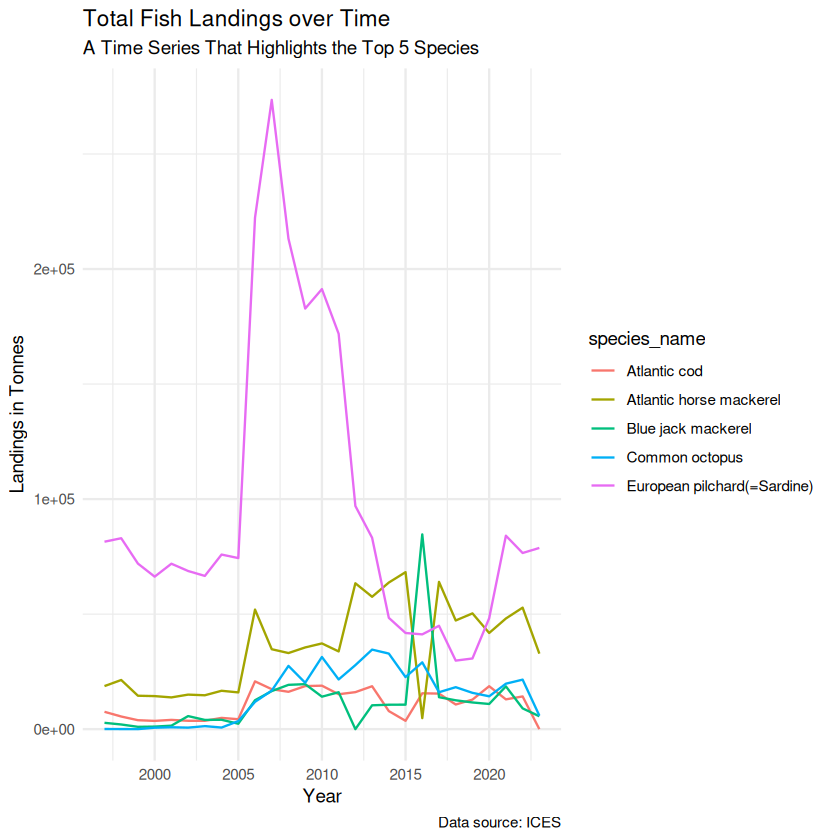

In [43]:
# First let's view the landings of the top 5 fished species
top_5_time_series <- ggplot(top_5_landings, aes(x = year, y = total_landings, color = species_name, group = species_name)) +
  geom_line() +
  labs(
    title = "Total Fish Landings over Time",
    subtitle = "A Time Series That Highlights the Top 5 Species",
    x = "Year",
    y = "Landings in Tonnes",
    caption = "Data source: ICES"
  ) +
  theme_minimal()

top_5_time_series

`summarise()` has grouped output by 'species_name'. You can override using the
`.groups` argument.


`stat_bin()` using `bins = 30`. Pick better value `binwidth`.


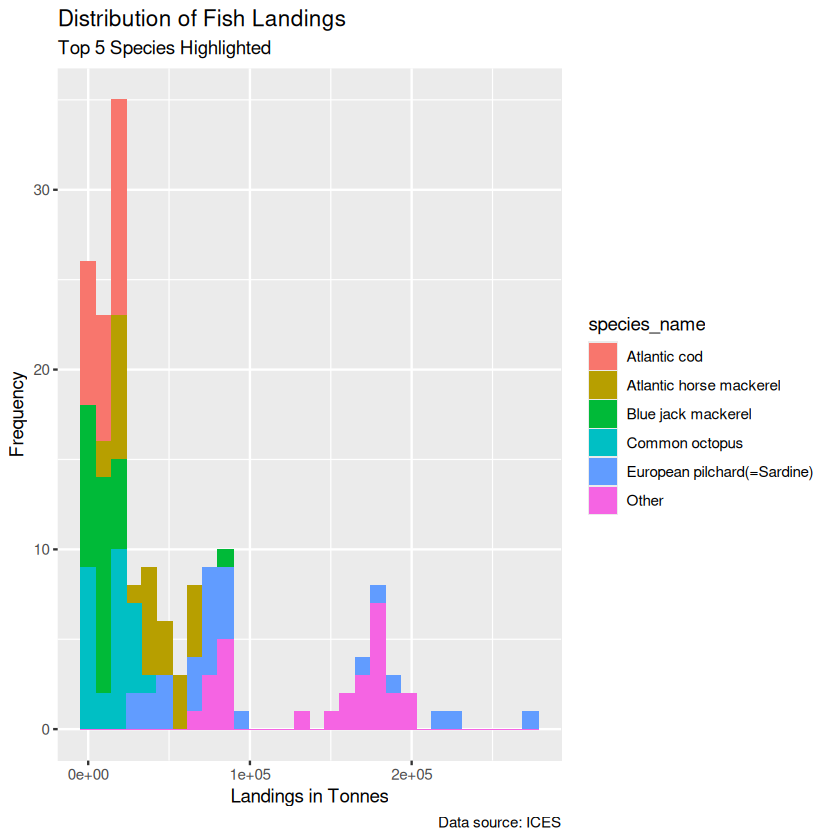

In [44]:
# Next let's see how much of the overall distribution of landings the top 5 species make up
landings_dist <- pt_landings %>%
  select(-"1950":-"1996", -"species_code") %>%
  pivot_longer(
    cols = "1997":"2006",
    names_to = "year",
    values_to = "landings") %>%
  mutate(species_name = ifelse(species_name %in% top_5_spec, species_name, "Other")) %>%
  group_by(species_name, year) %>% 
  summarise(total_landings = sum(landings, na.rm = TRUE)) %>%
  mutate(year = as.numeric(year))

# Create a histogram using ggplot
landings_dist_viz <- ggplot(landings_dist, aes(x = total_landings, fill = species_name)) +
  geom_histogram() +
  labs(
    title = "Distribution of Fish Landings",
    subtitle = "Top 5 Species Highlighted",  # Optional
    x = "Landings in Tonnes",
    y = "Frequency",
    caption = "Data source: ICES"  # Optional
  ) 

landings_dist_viz

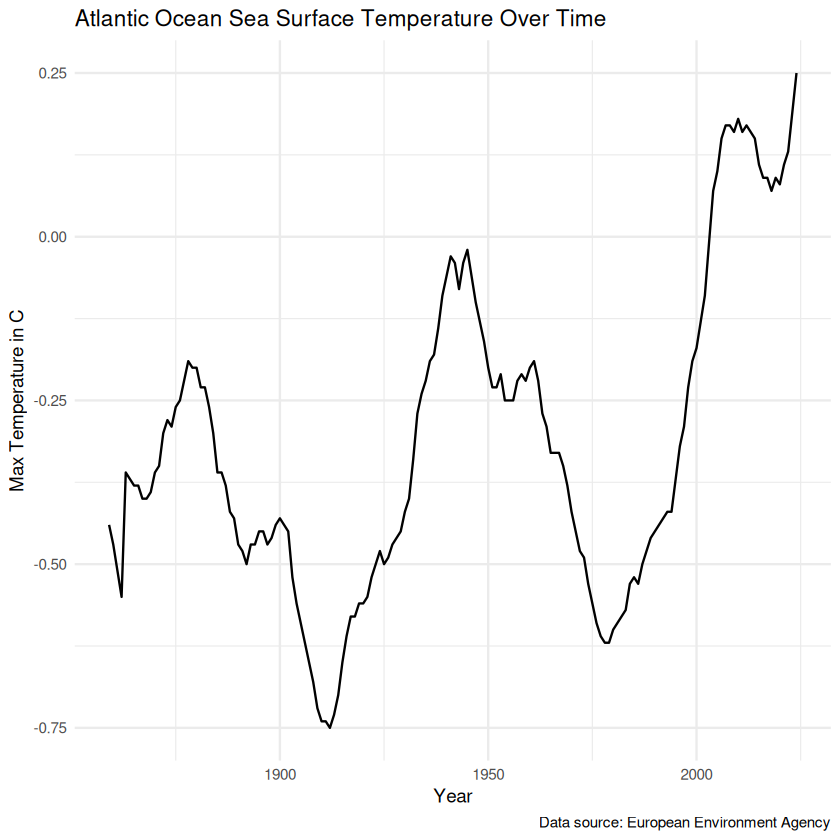

In [45]:
# Let's Look at How Temperature has Changed Over Time
# For this analysis, we'll only be focusing on the annual maximum temperatures
atl_clim_time_series <- ggplot(atl_clim_clean, aes(x = year, y = max_temp)) +
  geom_line() +
  labs(
    title = "Atlantic Ocean Sea Surface Temperature Over Time",
    x = "Year",
    y = "Max Temperature in C",
    caption = "Data source: European Environment Agency"  # Optional
  ) +
  theme_minimal()

atl_clim_time_series

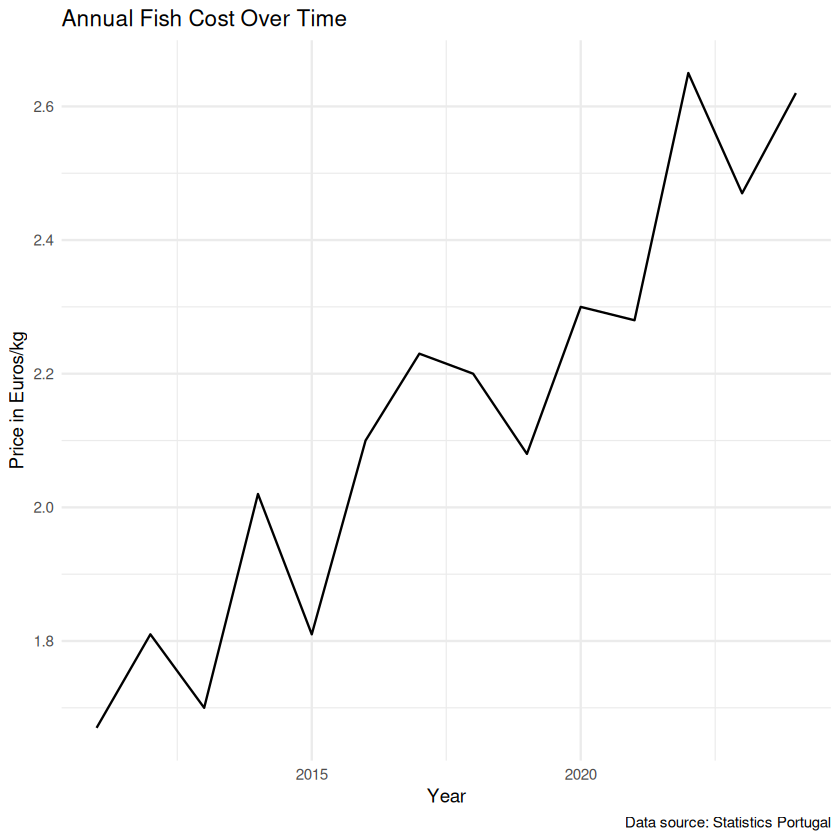

In [46]:
# Let's Look at How Annual Fish Cost has Changed Over Time
fish_cost_time_series <- ggplot(fish_cost_clean, aes(x = year, y = price)) +
  geom_line() +
  labs(
    title = "Annual Fish Cost Over Time",
    x = "Year",
    y = "Price in Euros/kg",
    caption = "Data source: Statistics Portugal"  # Optional
  ) +
  theme_minimal()

fish_cost_time_series

,year,price,max_temp,min_temp
,<int>,<dbl>,<dbl>,<dbl>
1,2024,2.62,0.25,0.19
2,2023,2.47,0.19,0.14
3,2022,2.65,0.13,0.07
4,2021,2.28,0.11,0.04
5,2020,2.30,0.08,0.01
6,2019,2.08,0.09,0.02


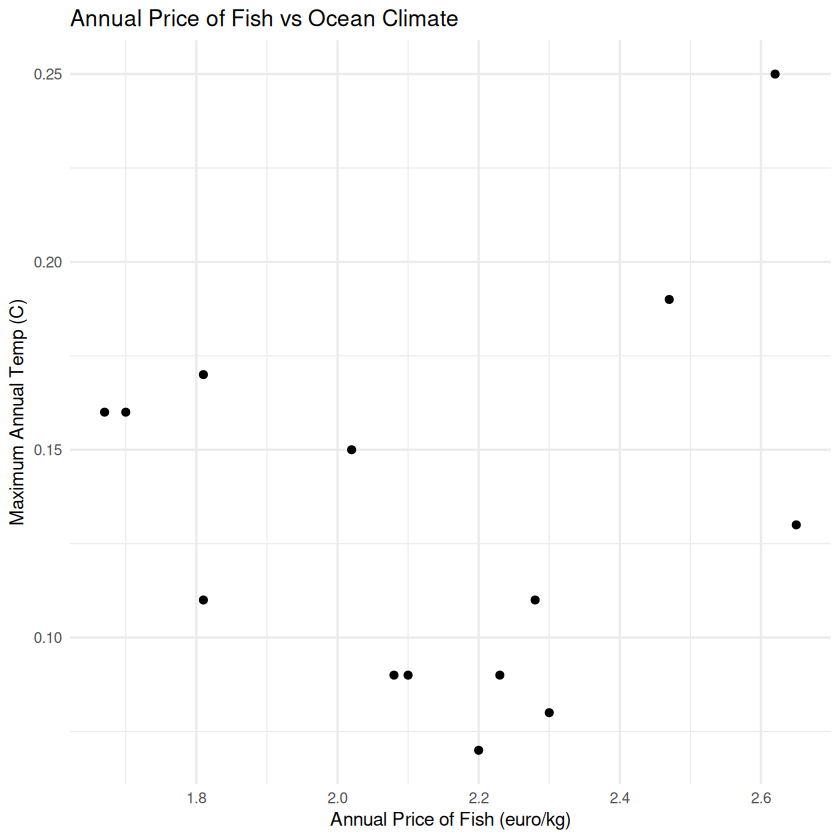

In [47]:
# Observe the Relationship Between Fish Cost and Ocean Temp
clim_and_cost <- fish_cost_clean %>%
  left_join(atl_clim_clean, by = "year")

head(clim_and_cost)

clim_cost_viz <- ggplot(clim_and_cost, aes(x = price, y = max_temp)) +
  geom_point() +
  labs(
    title = "Annual Price of Fish vs Ocean Climate",
    x = "Annual Price of Fish (euro/kg)",
    y = "Maximum Annual Temp (C)"
  ) +
  theme_minimal()

clim_cost_viz

species_code,species_name,year,total_landings,max_temp,min_temp,price
<chr>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
PIL,European pilchard(=Sardine),1997,81475,-0.29,-0.35,NA
PIL,European pilchard(=Sardine),1998,82985,-0.23,-0.30,NA
PIL,European pilchard(=Sardine),1999,71955,-0.19,-0.26,NA
PIL,European pilchard(=Sardine),2000,66283,-0.17,-0.24,NA
PIL,European pilchard(=Sardine),2001,71907,-0.13,-0.19,NA
PIL,European pilchard(=Sardine),2002,68739,-0.09,-0.15,NA


Warning message:
“Removed 14 rows containing missing values or values outside the scale range
(`geom_point()`).”


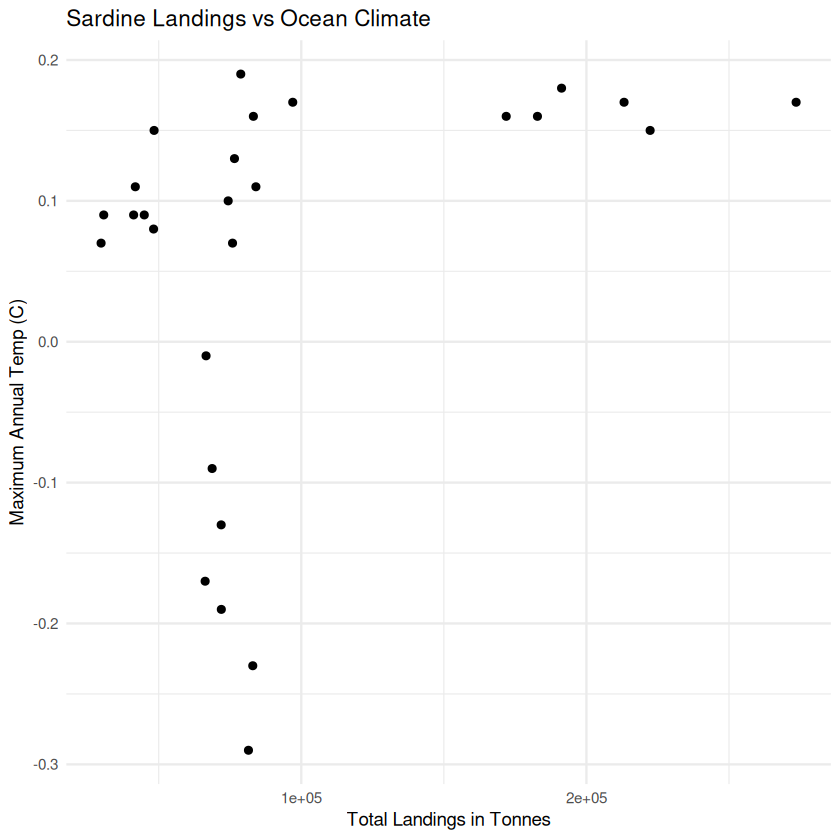

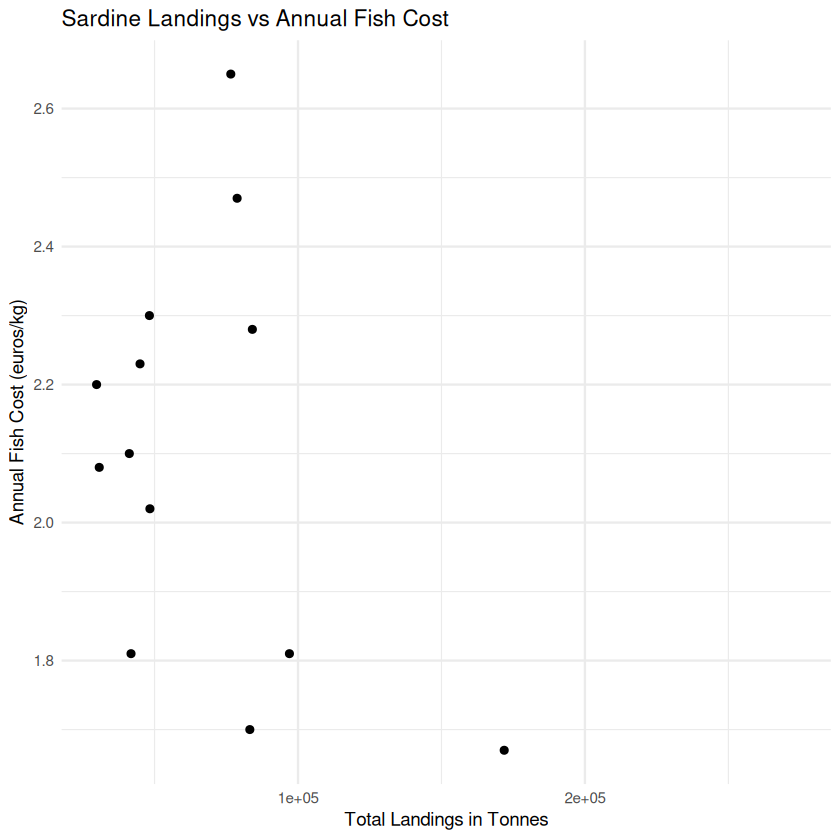

In [48]:
# Observe the Relationship Between Sardines Landings, Temp, and Fish Cost
sardine <- top_5_landings %>%
  filter(species_name == "European pilchard(=Sardine)") %>%
  left_join(atl_clim_clean, by = "year") %>%
  left_join(fish_cost_clean, by = "year")

head(sardine)

# Plot the Relationship Betweeen Sardines Landings and Temp
sardine_clim_viz <- ggplot(sardine, aes(x = total_landings, y = max_temp)) +
  geom_point() +
  labs(
    title = "Sardine Landings vs Ocean Climate",
    x = "Total Landings in Tonnes",
    y = "Maximum Annual Temp (C)"
  ) +
  theme_minimal()

sardine_clim_viz

# Plot the Relationship Betweeen Sardines Landings and Fish Cost
sardine_cost_viz <- ggplot(sardine, aes(x = total_landings, y = price)) +
  geom_point() +
  labs(
    title = "Sardine Landings vs Annual Fish Cost",
    x = "Total Landings in Tonnes",
    y = "Annual Fish Cost (euros/kg)"
  ) +
  theme_minimal()

sardine_cost_viz

species_code,species_name,year,total_landings,max_temp,min_temp,price
<chr>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
HOM,Atlantic horse mackerel,1997,18720,-0.29,-0.35,NA
HOM,Atlantic horse mackerel,1998,21364,-0.23,-0.30,NA
HOM,Atlantic horse mackerel,1999,14524,-0.19,-0.26,NA
HOM,Atlantic horse mackerel,2000,14362,-0.17,-0.24,NA
HOM,Atlantic horse mackerel,2001,13796,-0.13,-0.19,NA
HOM,Atlantic horse mackerel,2002,15009,-0.09,-0.15,NA


Warning message:
“Removed 14 rows containing missing values or values outside the scale range
(`geom_point()`).”


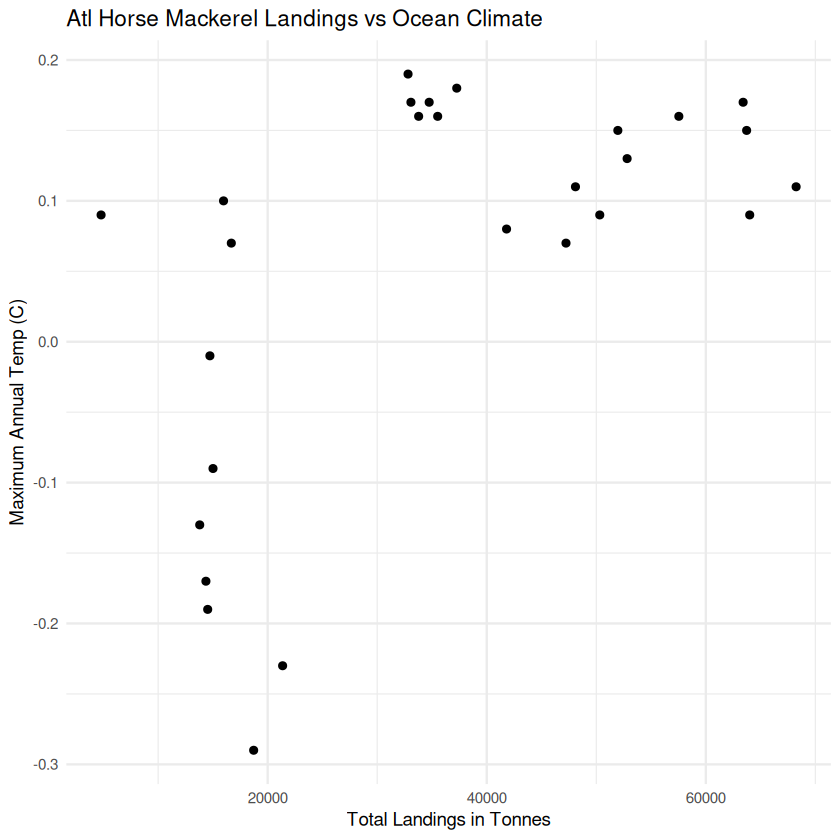

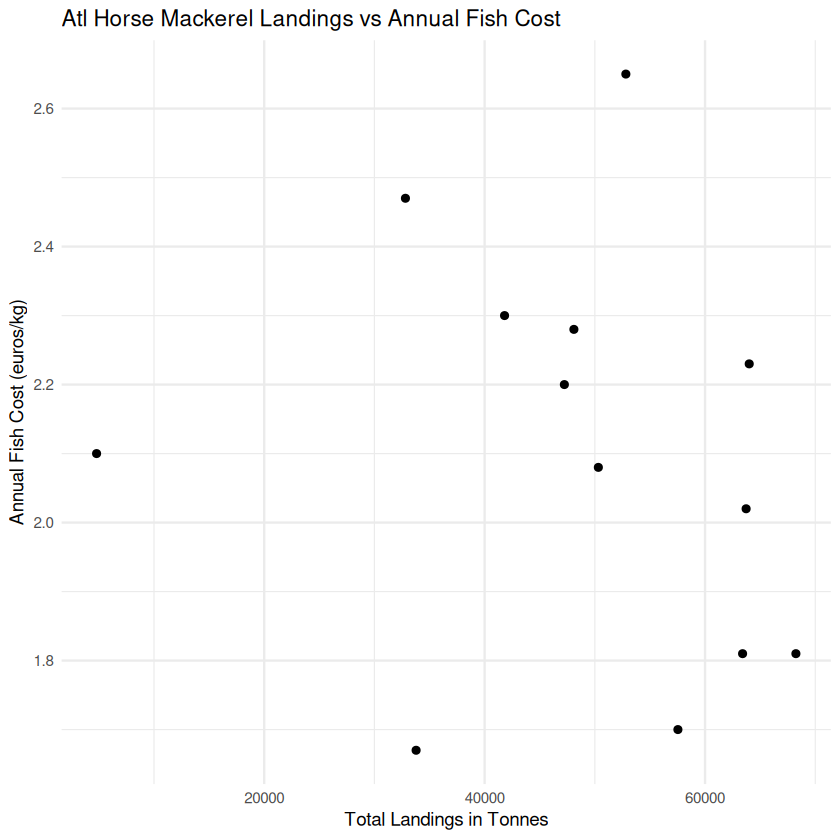

In [49]:
# Observe the Relationship Between Atlantc Horse Mackerel Landings, Temp, and Fish Cost
horse_mack <- top_5_landings %>%
  filter(species_name == "Atlantic horse mackerel") %>%
  left_join(atl_clim_clean, by = "year") %>%
  left_join(fish_cost_clean, by = "year")

head(horse_mack)

# Plot the Relationship Betweeen Atl Horse Mackerel Landings and Temp
horse_mack_clim_viz <- ggplot(horse_mack, aes(x = total_landings, y = max_temp)) +
  geom_point() +
  labs(
    title = "Atl Horse Mackerel Landings vs Ocean Climate",
    x = "Total Landings in Tonnes",
    y = "Maximum Annual Temp (C)"
  ) +
  theme_minimal()

horse_mack_clim_viz

# Plot the Relationship Betweeen Atl Horse Mackerel Landings and Fish Cost
horse_mack_cost_viz <- ggplot(horse_mack, aes(x = total_landings, y = price)) +
  geom_point() +
  labs(
    title = "Atl Horse Mackerel Landings vs Annual Fish Cost",
    x = "Total Landings in Tonnes",
    y = "Annual Fish Cost (euros/kg)"
  ) +
  theme_minimal()

horse_mack_cost_viz

species_code,species_name,year,total_landings,max_temp,min_temp,price
<chr>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
OCC,Common octopus,1997,63,-0.29,-0.35,NA
OCC,Common octopus,1998,38,-0.23,-0.30,NA
OCC,Common octopus,1999,12,-0.19,-0.26,NA
OCC,Common octopus,2000,624,-0.17,-0.24,NA
OCC,Common octopus,2001,823,-0.13,-0.19,NA
OCC,Common octopus,2002,660,-0.09,-0.15,NA


Warning message:
“Removed 14 rows containing missing values or values outside the scale range
(`geom_point()`).”


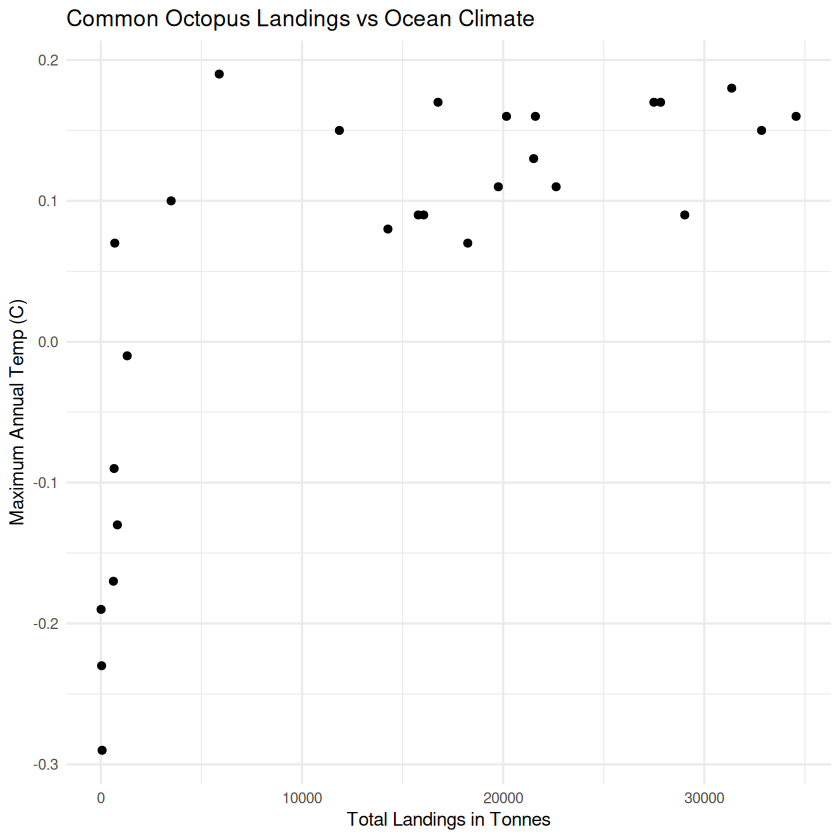

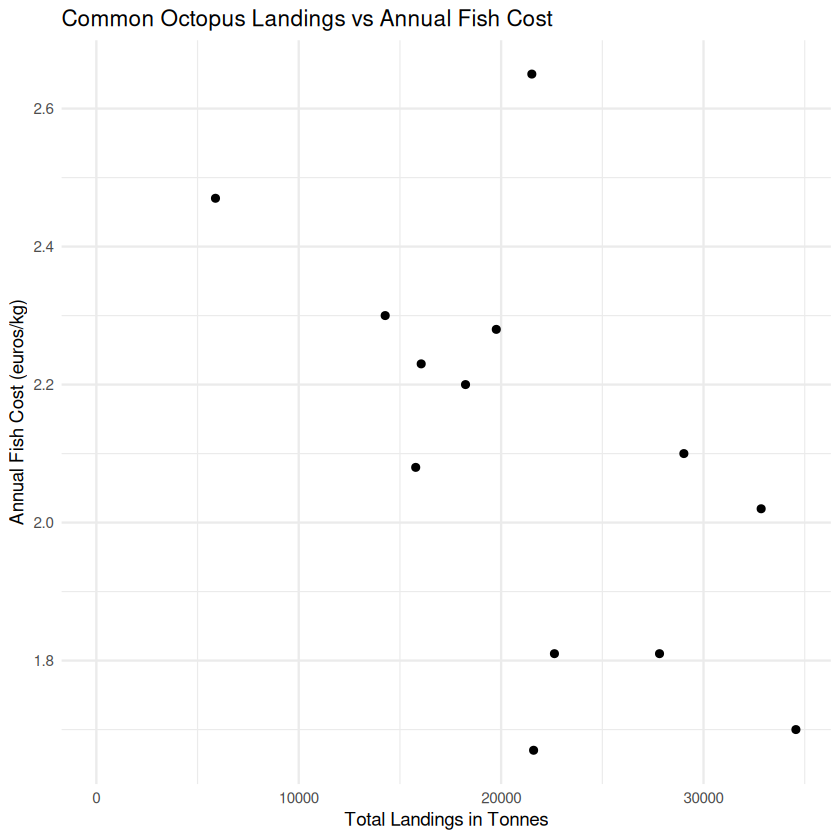

In [50]:
# Observe the Relationship Between Common Octopus Landings, Temp, and Fish Cost
common_oct <- top_5_landings %>%
  filter(species_name == "Common octopus") %>%
  left_join(atl_clim_clean, by = "year") %>%
  left_join(fish_cost_clean, by = "year")

head(common_oct)

# Plot the Relationship Betweeen Common Octopus Landings and Temp
commmon_oct_clim_viz <- ggplot(common_oct, aes(x = total_landings, y = max_temp)) +
  geom_point() +
  labs(
    title = "Common Octopus Landings vs Ocean Climate",
    x = "Total Landings in Tonnes",
    y = "Maximum Annual Temp (C)"
  ) +
  theme_minimal()

commmon_oct_clim_viz

# Plot the Relationship Betweeen Common Octopus Landings and Fish Cost
common_oct_cost_viz <- ggplot(common_oct, aes(x = total_landings, y = price)) +
  geom_point() +
  labs(
    title = "Common Octopus Landings vs Annual Fish Cost",
    x = "Total Landings in Tonnes",
    y = "Annual Fish Cost (euros/kg)"
  ) +
  theme_minimal()

common_oct_cost_viz

species_code,species_name,year,total_landings,max_temp,min_temp,price
<chr>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
JAA,Blue jack mackerel,1997,2752,-0.29,-0.35,NA
JAA,Blue jack mackerel,1998,2028,-0.23,-0.30,NA
JAA,Blue jack mackerel,1999,1010,-0.19,-0.26,NA
JAA,Blue jack mackerel,2000,1110,-0.17,-0.24,NA
JAA,Blue jack mackerel,2001,1509,-0.13,-0.19,NA
JAA,Blue jack mackerel,2002,5675,-0.09,-0.15,NA


Warning message:
“Removed 14 rows containing missing values or values outside the scale range
(`geom_point()`).”


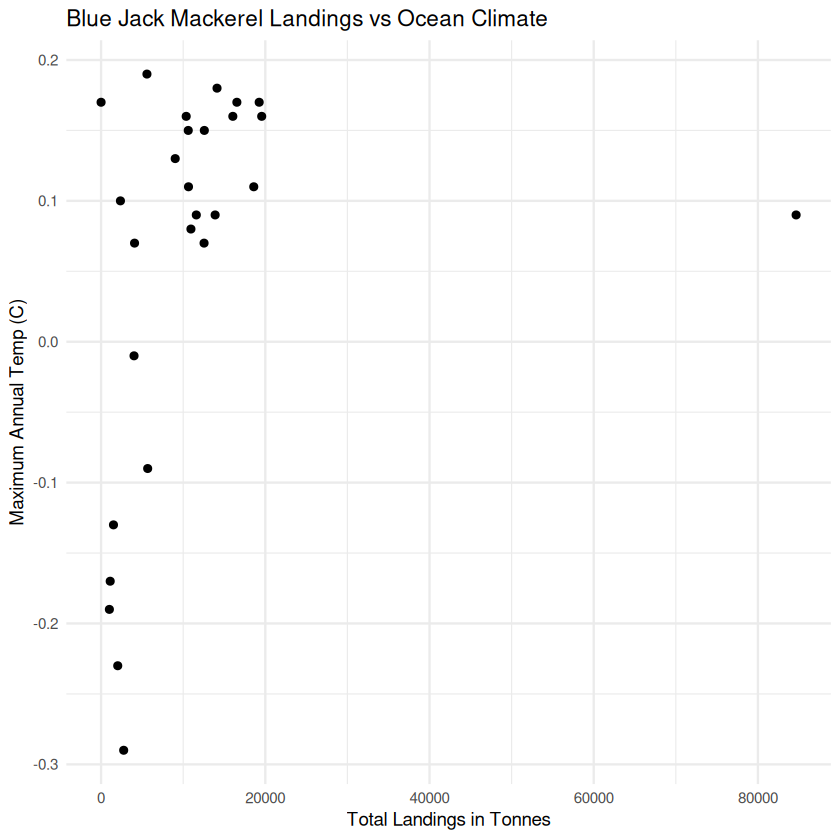

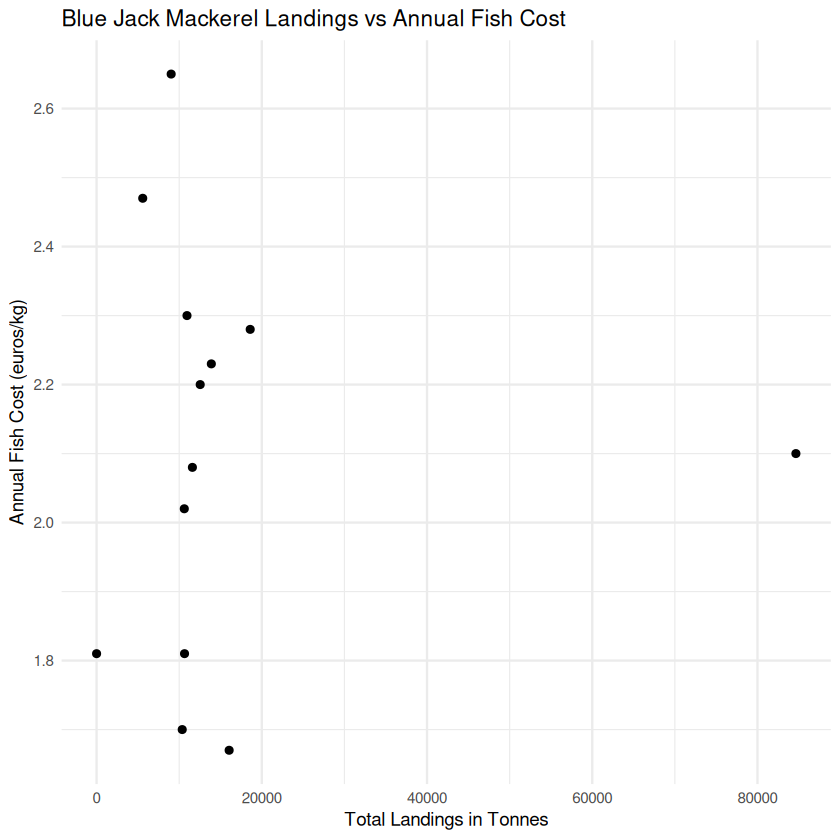

In [51]:
# Observe the Relationship Between Blue Jack Mackerel Landings, Temp, and Fish Cost
bl_jack <- top_5_landings %>%
  filter(species_name == "Blue jack mackerel") %>%
  left_join(atl_clim_clean, by = "year") %>%
  left_join(fish_cost_clean, by = "year")

head(bl_jack)

# Plot the Relationship Betweeen Blue Jack Mackerel Landings and Temp
bl_jack_clim_viz <- ggplot(bl_jack, aes(x = total_landings, y = max_temp)) +
  geom_point() +
  labs(
    title = "Blue Jack Mackerel Landings vs Ocean Climate",
    x = "Total Landings in Tonnes",
    y = "Maximum Annual Temp (C)"
  ) +
  theme_minimal()

bl_jack_clim_viz

# Plot the Relationship Betweeen Blue Jack Mackerel Landings and Fish Cost
bl_jack_cost_viz <- ggplot(bl_jack, aes(x = total_landings, y = price)) +
  geom_point() +
  labs(
    title = "Blue Jack Mackerel Landings vs Annual Fish Cost",
    x = "Total Landings in Tonnes",
    y = "Annual Fish Cost (euros/kg)"
  ) +
  theme_minimal()

bl_jack_cost_viz

species_code,species_name,year,total_landings,max_temp,min_temp,price
<chr>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
COD,Atlantic cod,1997,7533,-0.29,-0.35,NA
COD,Atlantic cod,1998,5493,-0.23,-0.30,NA
COD,Atlantic cod,1999,3885,-0.19,-0.26,NA
COD,Atlantic cod,2000,3587,-0.17,-0.24,NA
COD,Atlantic cod,2001,4028,-0.13,-0.19,NA
COD,Atlantic cod,2002,3630,-0.09,-0.15,NA


Warning message:
“Removed 14 rows containing missing values or values outside the scale range
(`geom_point()`).”


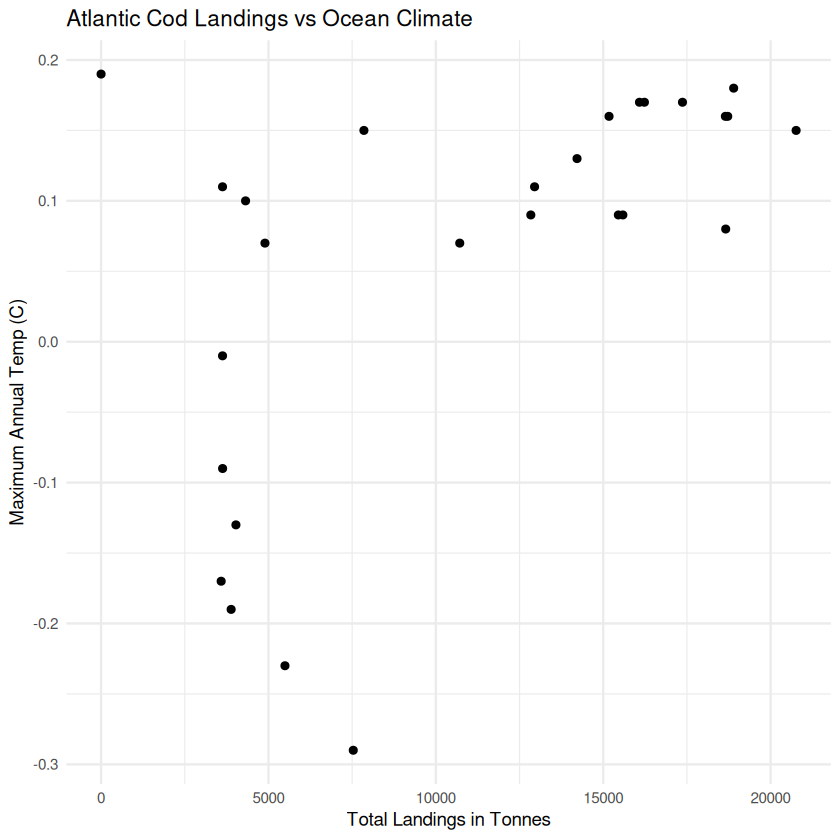

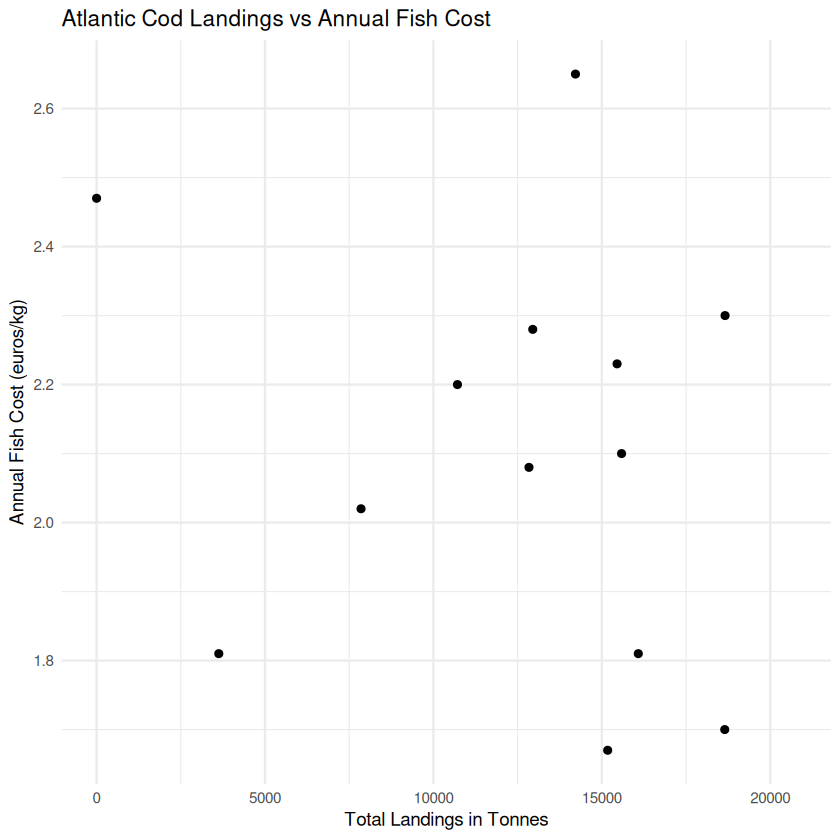

In [52]:
# Observe the Relationship Between Atlantic Cod Landings, Temp, and Fish Cost
atl_cod <- top_5_landings %>%
  filter(species_name == "Atlantic cod") %>%
  left_join(atl_clim_clean, by = "year") %>%
  left_join(fish_cost_clean, by = "year")

head(atl_cod)

# Plot the Relationship Betweeen Atlantic Cod Landings and Temp
atl_cod_clim_viz <- ggplot(atl_cod, aes(x = total_landings, y = max_temp)) +
  geom_point() +
  labs(
    title = "Atlantic Cod Landings vs Ocean Climate",
    x = "Total Landings in Tonnes",
    y = "Maximum Annual Temp (C)"
  ) +
  theme_minimal()

atl_cod_clim_viz

# Plot the Relationship Betweeen Atlantic Cod Landings and Fish Cost
atl_cod_cost_viz <- ggplot(atl_cod, aes(x = total_landings, y = price)) +
  geom_point() +
  labs(
    title = "Atlantic Cod Landings vs Annual Fish Cost",
    x = "Total Landings in Tonnes",
    y = "Annual Fish Cost (euros/kg)"
  ) +
  theme_minimal()

atl_cod_cost_viz

## Create CSV Files for Processed Data

In [52]:
# Create a CSV File for sum_pt_landings and top_5_landings
write.csv(pt_annual_landings, file = "pt_annual_landings.csv", row.names = FALSE)
write.csv(top_5_landings, file = "top_5_landings.csv", row.names = FALSE)
write.csv(clim_and_cost, file = "clim_and_cost.csv", row.names = FALSE)
write.csv(sardine, file = "sardine.csv", row.names = FALSE)
write.csv(horse_mack, file = "horse_mack.csv", row.names = FALSE)
write.csv(common_oct, file = "common_oct.csv", row.names = FALSE)
write.csv(bl_jack, file = "bl_jack.csv", row.names = FALSE)
write.csv(atl_cod, file = "atl_cod.csv", row.names = FALSE)
write.csv(top_5_landings, file = "top_5_landings.csv", row.names = FALSE)

In [53]:
# Move it to the processed_data folder

# Define the current and new file paths
# old_path <- "/home/user/github-cocalc-sync/pt-fisheries-climate-change/data/raw_data/[insert file name]" 
# Specify new directory and filename
# new_path <- "/home/user/github-cocalc-sync/pt-fisheries-climate-change/data/processed_data/[insert file name] 

# For example
old_path <- "/home/user/github-cocalc-sync/pt-fisheries-climate-change/data/raw_data/pt_annual_landings.csv" 
# Specify new directory and filename
new_path <- "/home/user/github-cocalc-sync/pt-fisheries-climate-change/data/processed_data/pt_annual_landings.csv" 

# Move the file
if (file.rename(old_path, new_path)) {
  print("File moved successfully.")
} else {
  print("File move failed.")
}

[1] "File moved successfully."
